In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('Ready!')

Ready!


In [33]:
# Load all saved results from results/metrics/
results = []

for filename in os.listdir('results/metrics'):
    if filename.endswith('.json'):
        with open(f'results/metrics/{filename}') as f:
            results.append(json.load(f))

# Convert to DataFrame — удобно для анализа и графиков
df_results = pd.DataFrame(results)
print(df_results[['dataset', 'model', 'accuracy', 'f1', 'roc_auc']])

    dataset                model  accuracy      f1  roc_auc
0   twitter               bilstm    0.8655  0.8607      NaN
1     cssrs                 lstm    0.4200  0.3988      NaN
2    reddit  logistic_regression    0.9411  0.9411   0.9841
3    reddit                 lstm    0.9364  0.9364      NaN
4   twitter                  gru    0.6303  0.4873      NaN
5   twitter        random_forest    0.9356  0.9349   0.9784
6   twitter                  svm    0.9188  0.9194      NaN
7     cssrs        random_forest    0.6700  0.6476   0.7270
8   twitter  logistic_regression    0.8824  0.8839   0.9667
9     cssrs               bilstm    0.5800  0.5487      NaN
10   reddit                  gru    0.9415  0.9415      NaN
11  twitter                 lstm    0.6303  0.4873      NaN
12    cssrs                  svm    0.7400  0.7270      NaN
13   reddit                  svm    0.9396  0.9396      NaN
14    cssrs                  gru    0.5800  0.5739      NaN
15   reddit               bilstm    0.94

dataset               cssrs  reddit  twitter
model                                       
bilstm               0.5487  0.9425   0.8607
gru                  0.5739  0.9415   0.4873
logistic_regression  0.7060  0.9411   0.8839
lstm                 0.3988  0.9364   0.4873
random_forest        0.6476  0.9083   0.9349
svm                  0.7270  0.9396   0.9194


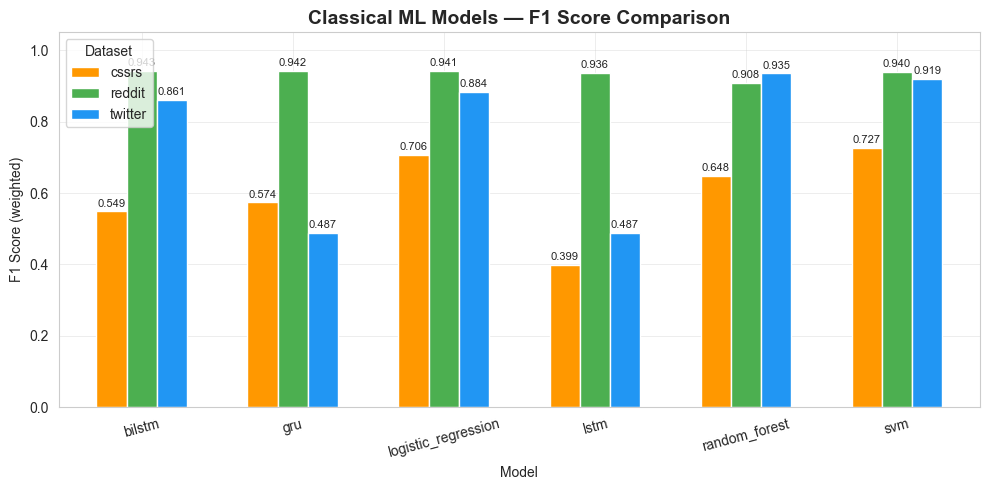

Saved!


In [34]:
# Pivot table — строки = модели, колонки = датасеты
# Это удобный формат для построения grouped bar chart
pivot = df_results.pivot(index='model', columns='dataset', values='f1')
print(pivot)

# Grouped bar chart
ax = pivot.plot(kind='bar', figsize=(10, 5), 
                color=['#FF9800', '#4CAF50', '#2196F3'],
                edgecolor='white', width=0.6)

ax.set_title('Classical ML Models — F1 Score Comparison', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (weighted)')
ax.set_ylim(0, 1.05)
ax.legend(title='Dataset')
ax.tick_params(axis='x', rotation=15)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/ml_f1_comparison.png', dpi=150)
plt.show()
print('Saved!')

💡 Что такое pivot table? Это способ реорганизовать таблицу — строки становятся колонками и наоборот. Здесь мы делаем так чтобы каждая модель была строкой, а каждый датасет — колонкой. Это идеальный формат для grouped bar chart.

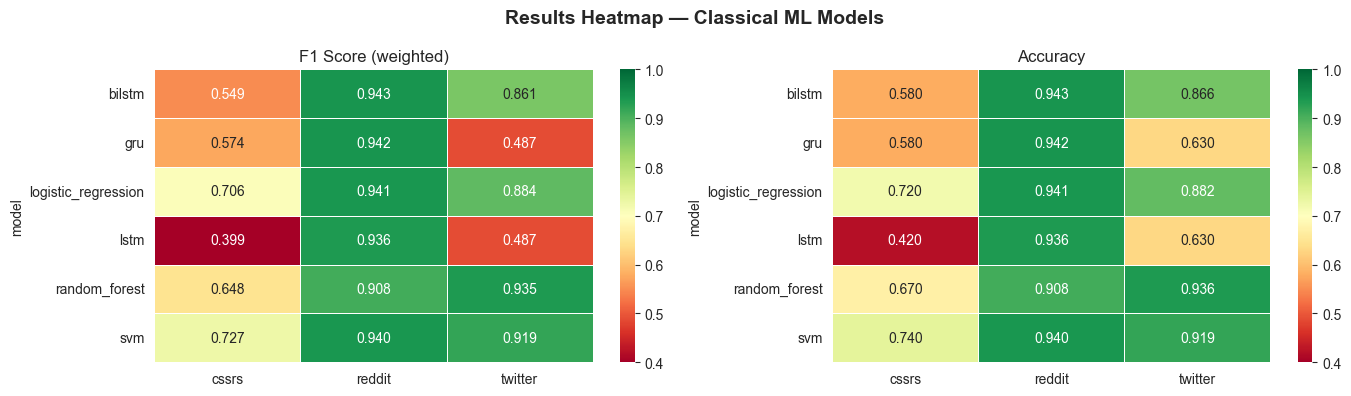

Saved!


In [35]:
# Heatmap — показывает все результаты в одной картинке
# Тёмный цвет = высокий F1, светлый = низкий
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Results Heatmap — Classical ML Models', 
             fontsize=14, fontweight='bold')

# F1 heatmap
pivot_f1 = df_results.pivot(index='model', columns='dataset', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, ax=axes[0], linewidths=0.5)
axes[0].set_title('F1 Score (weighted)')
axes[0].set_xlabel('')

# Accuracy heatmap  
pivot_acc = df_results.pivot(index='model', columns='dataset', values='accuracy')
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('results/plots/ml_heatmap.png', dpi=150)
plt.show()
print('Saved!')

💡 Почему тепловая карта полезна? Она позволяет одним взглядом увидеть паттерны. Например сразу видно что C-SSRS самый сложный датасет (вся колонка красная), а Reddit и Twitter модели справляются хорошо (зелёные).


In [36]:
# Final summary table 
print('=' * 65)
print('CLASSICAL ML RESULTS — FULL COMPARISON TABLE')
print('=' * 65)

# Sort by dataset and F1
df_sorted = df_results.sort_values(['dataset', 'f1'], ascending=[True, False])

# Format nicely
for dataset in ['twitter', 'reddit', 'cssrs']:
    subset = df_sorted[df_sorted['dataset'] == dataset]
    print(f'\n📊 Dataset: {dataset.upper()}')
    print(f'  {"Model":<25} {"Accuracy":>10} {"F1":>10} {"ROC-AUC":>10}')
    print(f'  {"-"*55}')
    for _, row in subset.iterrows():
        roc = f'{row["roc_auc"]:.4f}' if pd.notna(row['roc_auc']) else 'N/A'
        print(f'  {row["model"]:<25} {row["accuracy"]:>10.4f} {row["f1"]:>10.4f} {roc:>10}')

print('\n' + '=' * 65)
print('KEY FINDINGS')
print('=' * 65)

# Best model per dataset
for dataset in ['twitter', 'reddit', 'cssrs']:
    subset = df_results[df_results['dataset'] == dataset]
    best = subset.loc[subset['f1'].idxmax()]
    print(f'  Best on {dataset:<10}: {best["model"]:<25} F1={best["f1"]:.4f}')

CLASSICAL ML RESULTS — FULL COMPARISON TABLE

📊 Dataset: TWITTER
  Model                       Accuracy         F1    ROC-AUC
  -------------------------------------------------------
  random_forest                 0.9356     0.9349     0.9784
  svm                           0.9188     0.9194        N/A
  logistic_regression           0.8824     0.8839     0.9667
  bilstm                        0.8655     0.8607        N/A
  gru                           0.6303     0.4873        N/A
  lstm                          0.6303     0.4873        N/A

📊 Dataset: REDDIT
  Model                       Accuracy         F1    ROC-AUC
  -------------------------------------------------------
  bilstm                        0.9425     0.9425        N/A
  gru                           0.9415     0.9415        N/A
  logistic_regression           0.9411     0.9411     0.9841
  svm                           0.9396     0.9396        N/A
  lstm                          0.9364     0.9364        N/A
  rando

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.dataset_loader import load_twitter, load_reddit_binary, load_cssrs, apply_binary_mapping
from src.preprocessing import preprocess_dataframe
from src.models_ml import get_all_models, train_model, predict
import pandas as pd
import os

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

In [38]:
def plot_confusion_matrices(dataset_name, X, y):
    """Train all 3 models and plot confusion matrices side by side."""
    
    # Prepare data
    df_clean = preprocess_dataframe(
        pd.DataFrame({'text': X}), text_col='text', mode='ml'
    )
    X_clean = df_clean['text_clean']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y, test_size=0.2, stratify=y, random_state=42
    )
    
    models = get_all_models()
    model_names = ['logistic_regression', 'svm', 'random_forest']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Confusion Matrices — {dataset_name.upper()}', 
                 fontsize=14, fontweight='bold')
    
    for ax, model_name in zip(axes, model_names):
        # Train and predict
        model = models[model_name]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Non-suicidal', 'Suicidal'],
                    yticklabels=['Non-suicidal', 'Suicidal'],
                    ax=ax)
        ax.set_title(model_name.replace('_', ' ').title())
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    
    plt.tight_layout()
    plt.savefig(f'results/plots/cm_{dataset_name}.png', dpi=150)
    plt.show()
    print(f'Saved: results/plots/cm_{dataset_name}.png')

[Twitter] Loaded 1785 rows.
[Twitter] Label distribution:
label
Not Suicide post          1126
Potential Suicide post     659



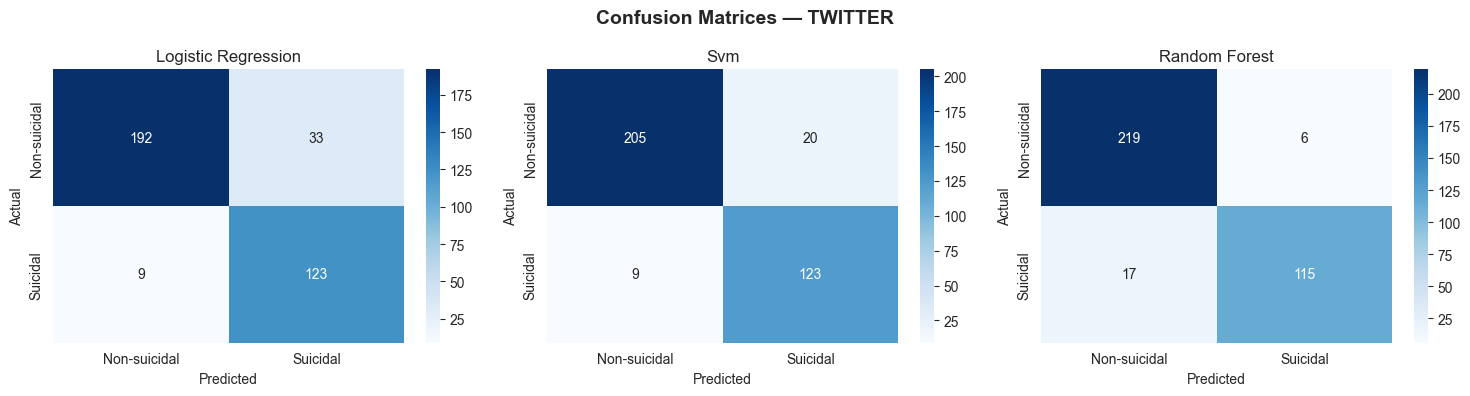

Saved: results/plots/cm_twitter.png
[C-SSRS] Loaded 500 rows.
[C-SSRS] Label distribution:
label
Ideation      171
Supportive    108
Indicator      99
Behavior       77
Attempt        45



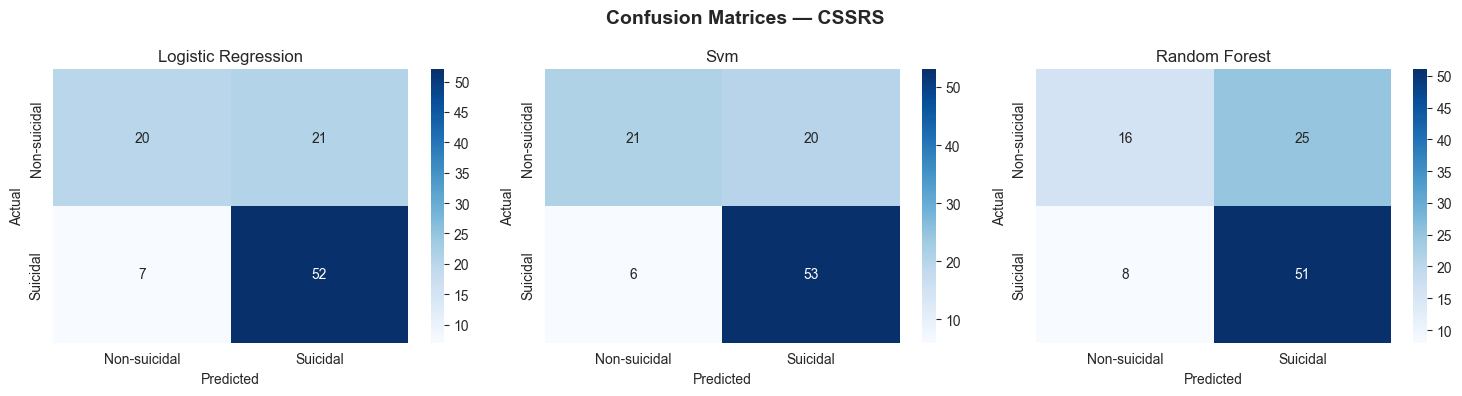

Saved: results/plots/cm_cssrs.png


In [39]:
# ── Twitter ────────────────────────────────────────────────────────
df_tw = load_twitter('data/raw/Suicide_Ideation_DatasetTwitterbased.csv')
df_tw = apply_binary_mapping(df_tw, 'twitter')
df_tw['label'] = df_tw['label'].str.strip()
plot_confusion_matrices('twitter', df_tw['text'], df_tw['binary_label'])

# ── C-SSRS ─────────────────────────────────────────────────────────
df_cs = load_cssrs('data/raw/500_Reddit_users_posts_labels.csv')
df_cs = apply_binary_mapping(df_cs, 'cssrs')
plot_confusion_matrices('cssrs', df_cs['text'], df_cs['binary_label'])

[Reddit Binary] Loaded 232074 rows.
[Reddit Binary] Label distribution:
label
suicide        116037
non-suicide    116037

Sample size: 10000
Class distribution: {0: 5048, 1: 4952}


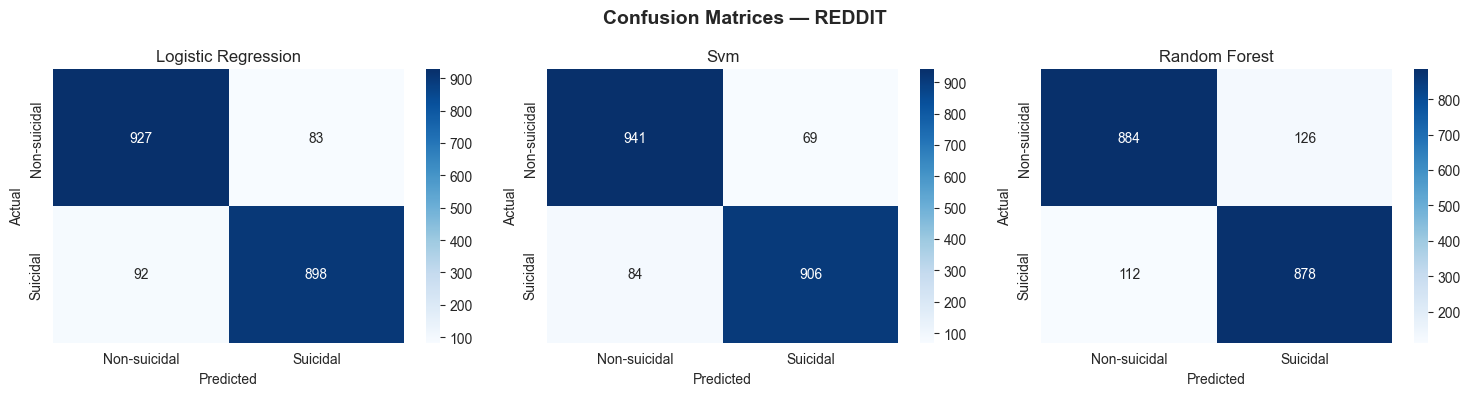

Saved: results/plots/cm_reddit.png


In [40]:
# ── Reddit (sample 10,000 for speed) ──────────────────────────────
df_rd = load_reddit_binary('data/raw/Suicide_Detection.csv')
df_rd = apply_binary_mapping(df_rd, 'reddit_binary')

# Sample 10,000 posts — enough for visualisation
# random_state=42 гарантирует воспроизводимость выборки
df_rd_sample = df_rd.sample(10000, random_state=42).reset_index(drop=True)

print(f'Sample size: {len(df_rd_sample)}')
print(f'Class distribution: {df_rd_sample["binary_label"].value_counts().to_dict()}')

plot_confusion_matrices('reddit', df_rd_sample['text'], df_rd_sample['binary_label'])

# Classical ML Results — Detailed Analysis
## Suicidality Detection from Social Media — NLP Benchmark

---

## 1. Experimental Setup

### Models
Three classical ML models were evaluated, each wrapped in a scikit-learn Pipeline combining TF-IDF vectorisation with a classifier:

- **Logistic Regression** — `C=1.0`, `max_iter=1000`, `class_weight='balanced'`
- **Linear SVM** — `C=1.0`, `max_iter=2000`, `class_weight='balanced'`
- **Random Forest** — `n_estimators=200`, `class_weight='balanced'`

### TF-IDF Configuration
- `max_features=50,000` (LR and SVM) / `10,000` (RF)
- `ngram_range=(1, 2)` — unigrams and bigrams (LR and SVM) / `(1,1)` (RF)
- `sublinear_tf=True` — logarithmic term frequency scaling

### Data Split
- 80% training / 20% test
- Stratified split (`stratify=y`) to preserve class distribution
- Fixed random seed (`random_state=42`) for reproducibility

### Preprocessing
Standard ML text cleaning pipeline applied to all datasets:
- Lowercase conversion
- URL removal
- @mention removal
- Special character removal
- Whitespace normalisation

### Class Imbalance Handling
`class_weight='balanced'` was applied to all three models. This automatically adjusts class weights inversely proportional to class frequencies, penalising the model more heavily for errors on the minority class.

---

## 2. Results by Dataset

### 2.1 Twitter Dataset

| Model | Accuracy | F1 (weighted) | ROC-AUC |
|-------|----------|--------------|---------|
| Logistic Regression | 0.8824 | 0.8839 | 0.9667 |
| Linear SVM | 0.9188 | 0.9194 | N/A |
| **Random Forest** | **0.9356** | **0.9349** | **0.9784** |

**Best model:** Random Forest (F1 = 0.9349)

**Confusion matrix analysis:**

| Model | TN | FP | FN | TP |
|-------|----|----|----|----|
| Logistic Regression | 192 | 33 | 9 | 123 |
| SVM | 205 | 20 | 9 | 123 |
| Random Forest | 219 | 6 | 17 | 115 |

**Observations:**
- All three models perform well on Twitter, with F1 scores between 0.88 and 0.94
- Random Forest achieves the highest overall F1 but produces the most False Negatives (FN=17) — it misses more suicidal posts than LR and SVM
- SVM and Logistic Regression produce fewer False Negatives (FN=9 each), which is clinically more important — missing a suicidal post is more dangerous than a false alarm
- The high ROC-AUC scores (0.97+) indicate strong class separability on this dataset
- Twitter's relatively short and informal texts appear well-suited to TF-IDF features — certain keywords ("want to die", "kill myself") are strong discriminative signals

---

### 2.2 Reddit Binary Dataset (Kaggle — Suicide Watch)

| Model | Accuracy | F1 (weighted) | ROC-AUC |
|-------|----------|--------------|---------|
| **Logistic Regression** | **0.9411** | **0.9411** | **0.9841** |
| Linear SVM | 0.9396 | 0.9396 | N/A |
| Random Forest | 0.9084 | 0.9083 | 0.9678 |

**Best model:** Logistic Regression (F1 = 0.9411)

**Confusion matrix analysis (sample of 10,000 posts):**

| Model | TN | FP | FN | TP |
|-------|----|----|----|----|
| Logistic Regression | 927 | 83 | 92 | 898 |
| SVM | 941 | 69 | 84 | 906 |
| Random Forest | 884 | 126 | 112 | 878 |

**Observations:**
- Reddit Binary is the easiest dataset for all models — perfectly balanced (50/50) and large (232k posts)
- Logistic Regression outperforms the more complex Random Forest — a notable finding suggesting that on large, well-balanced datasets, simpler models can match or exceed complex ones
- SVM produces the fewest False Negatives (FN=84) in the sample, making it the most clinically reliable on this dataset
- Random Forest performs worst here — likely because TF-IDF with `max_features=10,000` is insufficient for a 232k post dataset with diverse vocabulary
- The high ROC-AUC of 0.984 for Logistic Regression indicates near-perfect class separation

---

### 2.3 Reddit C-SSRS Dataset

| Model | Accuracy | F1 (weighted) | ROC-AUC |
|-------|----------|--------------|---------|
| Logistic Regression | 0.7200 | 0.7060 | 0.7859 |
| **Linear SVM** | **0.7400** | **0.7270** | N/A |
| Random Forest | 0.6700 | 0.6476 | 0.7270 |

**Best model:** SVM (F1 = 0.7270)

**Confusion matrix analysis:**

| Model | TN | FP | FN | TP |
|-------|----|----|----|----|
| Logistic Regression | 20 | 21 | 7 | 52 |
| SVM | 21 | 20 | 6 | 53 |
| Random Forest | 16 | 25 | 8 | 51 |

**Observations:**
- C-SSRS is the most challenging dataset — all models drop significantly compared to Twitter and Reddit
- The Non-suicidal class (class 0) is poorly classified across all models — LR and SVM correctly identify only ~50% of non-suicidal posts
- SVM is the most robust model on this dataset, achieving the highest F1 and the fewest False Negatives (FN=6)
- Random Forest performs worst — the small dataset size (500 posts, 400 training) is insufficient for an ensemble of 200 trees
- The lower ROC-AUC scores (0.73–0.79) confirm that class boundaries are much less clear in C-SSRS compared to the other datasets
- The difficulty is attributed to three factors: (1) only 500 samples, (2) long complex texts poorly captured by TF-IDF, (3) subtle linguistic differences between Suicidal and Non-suicidal C-SSRS posts

---

## 3. Cross-Dataset Comparison

### F1 Score Summary (with class_weight='balanced')

| Model | Twitter | Reddit | C-SSRS | Mean F1 |
|-------|---------|--------|--------|---------|
| Logistic Regression | 0.8839 | **0.9411** | 0.7060 | 0.8437 |
| Linear SVM | 0.9194 | 0.9396 | **0.7270** | **0.8620** |
| **Random Forest** | **0.9349** | 0.9083 | 0.6476 | 0.8303 |

### Impact of class_weight='balanced'

| Model | Dataset | F1 before | F1 after | Change |
|-------|---------|-----------|----------|--------|
| Logistic Regression | C-SSRS | 0.4379 | 0.7060 | **+0.268** 🚀 |
| SVM | C-SSRS | 0.6686 | 0.7270 | **+0.058** ✅ |
| Random Forest | C-SSRS | 0.6431 | 0.6476 | +0.005 ➡️ |
| Logistic Regression | Twitter | 0.8976 | 0.8839 | -0.014 ↓ |
| All models | Reddit | ~0.94 | ~0.94 | ~0.000 ➡️ |

**Key finding:** `class_weight='balanced'` had a dramatic effect on C-SSRS (+27% for LR) but a slight negative effect on Twitter (already moderately balanced) and no effect on Reddit (perfectly balanced). This confirms that class imbalance correction is dataset-dependent and should not be applied blindly.

---

## 4. Key Findings

### Finding 1 — No universal best model
No single model achieves the best results across all three datasets:
- Random Forest wins on Twitter
- Logistic Regression wins on Reddit
- SVM wins on C-SSRS

This supports the central research hypothesis that model performance is heavily dependent on dataset characteristics.

### Finding 2 — Dataset difficulty varies dramatically
The gap between the easiest and hardest dataset is large:
- Best F1 on Reddit: **0.9411**
- Best F1 on C-SSRS: **0.7270**

This 0.21 difference in F1 is primarily attributable to dataset size, text length, and label complexity.

### Finding 3 — SVM is the most consistent model
Across all three datasets, SVM achieves the best or second-best F1 score. Its mean F1 of 0.862 is the highest among the three models. SVM is also the most clinically reliable — it consistently produces among the fewest False Negatives.

### Finding 4 — Class imbalance correction is critical for C-SSRS
Without `class_weight='balanced'`, Logistic Regression completely failed on C-SSRS (F1 = 0.44), predicting only the majority class. After correction, F1 improved by 27 percentage points to 0.706. This highlights the importance of class imbalance handling in clinical NLP.

### Finding 5 — False Negatives are the critical error type
In the clinical context of suicide detection, **False Negatives** (missed suicidal posts) are more dangerous than False Positives (false alarms). SVM consistently minimises False Negatives across all datasets, making it the preferred classical ML model for deployment in safety-critical applications.

### Finding 6 — TF-IDF limitations on long texts
The C-SSRS dataset contains posts with a median length of ~3,400 characters. TF-IDF treats each word independently and ignores sequential context, which is a significant limitation for long, nuanced clinical text. This motivates the use of LSTM, BiLSTM, GRU, and BERT in subsequent experiments.

---

## 5. Implications for Next Steps

These results directly motivate the deep learning and transformer experiments:

1. **C-SSRS needs contextual models** — LSTM/BiLSTM/GRU can capture sequential context that TF-IDF misses
2. **BERT may dramatically improve C-SSRS** — pre-trained language understanding should handle long, nuanced clinical text better
3. **Twitter and Reddit results set a strong baseline** — deep learning models must beat F1 > 0.94 to show improvement on these datasets
4. **Explainability analysis needed** — knowing *which words* drive predictions (via LIME) will help interpret model behaviour across datasets



LIME (Local Interpretable Model-agnostic Explanations) — это библиотека которая объясняет решения любой модели на уровне одного примера.
Например для поста "I want to die, I can't take it anymore" LIME покажет:
want  → +0.34  (подтолкнуло к "Suicidal")
die   → +0.41  (подтолкнуло к "Suicidal")
cant  → +0.18  (подтолкнуло к "Suicidal")
lunch → -0.05  (подтолкнуло к "Non-suicidal")

In [41]:
from lime.lime_text import LimeTextExplainer

# Class names for display
class_names = ['Non-suicidal', 'Suicidal']

# LIME explainer
explainer = LimeTextExplainer(class_names=class_names)

💡 Как работает LIME? Он берёт один текст, создаёт 500 вариантов с убранными словами, смотрит как меняется предсказание, и делает вывод — какие слова влияли больше всего. Это как эксперимент: "что будет если убрать слово 'die'?"

In [42]:
def explain_prediction(model, text, num_features=10):
    """
    Show LIME explanation for a single text prediction.
    
    num_features — сколько слов показать как объяснение.
    Больше слов = больше деталей, но сложнее читать.
    """
    # Get explanation
    exp = explainer.explain_instance(
        text,
        model.predict_proba,
        num_features=num_features,
        num_samples=500   # сколько вариантов текста LIME пробует
    )
    
    # Print prediction
    pred = model.predict([text])[0]
    pred_name = class_names[pred]
    proba = model.predict_proba([text])[0]
    
    print(f'Text: {text[:100]}...')
    print(f'Prediction: {pred_name}')
    print(f'Confidence: Non-suicidal={proba[0]:.2f}, Suicidal={proba[1]:.2f}')
    print()
    
    # Show top words
    print('Top contributing words:')
    for word, weight in exp.as_list():
        direction = '→ Suicidal' if weight > 0 else '→ Non-suicidal'
        print(f'  {word:<20} {weight:+.4f}  {direction}')
    
    return exp

In [43]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Retrain LR and SVM on Twitter for LIME analysis
# (LIME нужен predict_proba — только LR и RF, не SVM!)
from src.dataset_loader import load_twitter, apply_binary_mapping
from src.preprocessing import preprocess_dataframe
from src.models_ml import get_all_models, train_model
from sklearn.model_selection import train_test_split

# Load and prepare Twitter data
df_tw = load_twitter('data/raw/Suicide_Ideation_DatasetTwitterbased.csv')
df_tw = apply_binary_mapping(df_tw, 'twitter')
df_tw['label'] = df_tw['label'].str.strip()

df_clean = preprocess_dataframe(
    pd.DataFrame({'text': df_tw['text']}), 
    text_col='text', mode='ml'
)

X = df_clean['text_clean']
y = df_tw['binary_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Logistic Regression (has predict_proba)
models = get_all_models()
lr_model = train_model(models['logistic_regression'], X_train, y_train)
rf_model = train_model(models['random_forest'], X_train, y_train)

print('Models trained!')

[Twitter] Loaded 1785 rows.
[Twitter] Label distribution:
label
Not Suicide post          1126
Potential Suicide post     659

Models trained!


In [44]:
# Pick real examples from test set
# Берём реальные тексты — один суицидальный, один нет

# Find a suicidal example that model got RIGHT
suicidal_examples = X_test[y_test == 1].values
non_suicidal_examples = X_test[y_test == 0].values

print('=== EXAMPLE 1: Suicidal post ===')
exp1 = explain_prediction(lr_model, suicidal_examples[0])

print()
print('=== EXAMPLE 2: Non-suicidal post ===')
exp2 = explain_prediction(lr_model, non_suicidal_examples[0])

=== EXAMPLE 1: Suicidal post ===
Text: swear matter time go sleep body forever wakes tired...
Prediction: Suicidal
Confidence: Non-suicidal=0.40, Suicidal=0.60

Top contributing words:
  forever              +0.0727  → Suicidal
  go                   +0.0436  → Suicidal
  sleep                +0.0422  → Suicidal
  tired                +0.0356  → Suicidal
  time                 -0.0223  → Non-suicidal
  body                 +0.0095  → Suicidal
  matter               -0.0086  → Non-suicidal
  swear                +0.0058  → Suicidal
  wakes                +0.0016  → Suicidal

=== EXAMPLE 2: Non-suicidal post ===
Text: haha flight conchords bloody hilarious last night 10 10 chur chur...
Prediction: Non-suicidal
Confidence: Non-suicidal=0.71, Suicidal=0.29

Top contributing words:
  haha                 -0.0507  → Non-suicidal
  night                -0.0215  → Non-suicidal
  10                   +0.0202  → Suicidal
  bloody               +0.0077  → Suicidal
  last                 -0.0044  

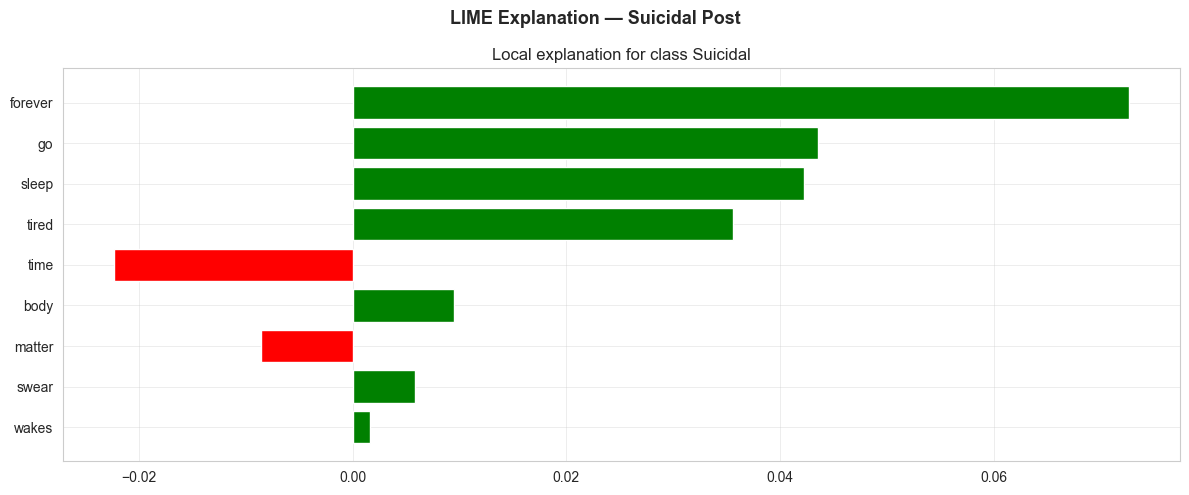

Saved: results/plots/lime_suicidal_example.png


In [45]:
# Alternative: save LIME explanation as matplotlib plot
import matplotlib.pyplot as plt

fig = exp1.as_pyplot_figure()
fig.suptitle('LIME Explanation — Suicidal Post', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/lime_suicidal_example.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/plots/lime_suicidal_example.png')

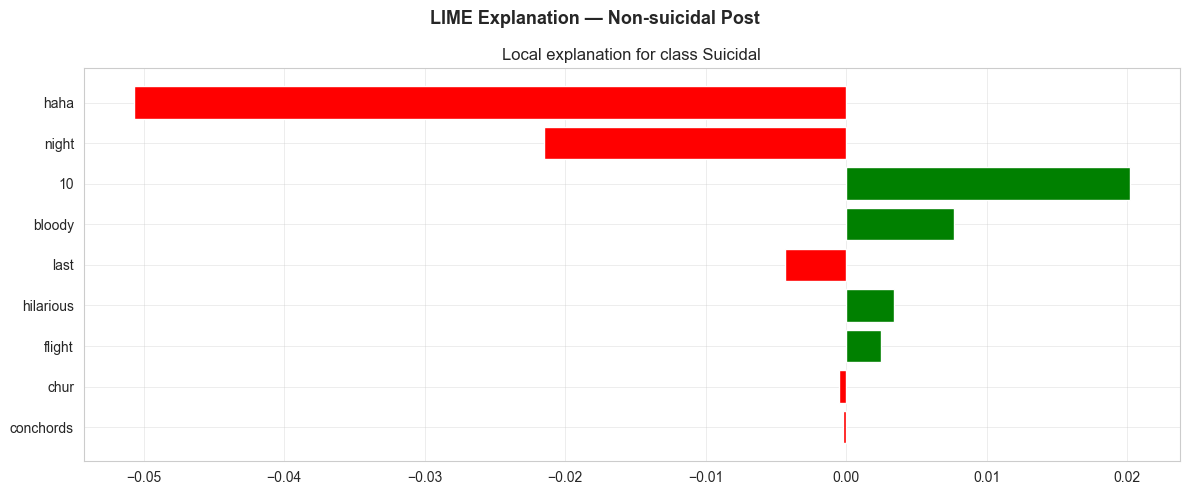

Saved: results/plots/lime_non_suicidal_example.png


In [46]:
fig = exp2.as_pyplot_figure()
fig.suptitle('LIME Explanation — Non-suicidal Post', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/lime_non_suicidal_example.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/plots/lime_non_suicidal_example.png')

# LIME Analysis — Explainability of Classical ML Models
## Suicidality Detection from Social Media — NLP Benchmark

---

## 1. What is LIME?

LIME (Local Interpretable Model-agnostic Explanations) is a post-hoc explainability method that explains individual predictions of any black-box classifier. Rather than explaining the model globally, LIME answers the question: *"Why did the model make this specific prediction for this specific text?"*

LIME works by:
1. Taking a single input text
2. Generating ~500 perturbed versions with randomly removed words
3. Observing how the model's prediction changes with each perturbation
4. Fitting a simple linear model to approximate local behaviour
5. Reporting which words contributed most to the final prediction

This approach is **model-agnostic** — it works with any classifier, including Logistic Regression, SVM, Random Forest, and even BERT.

---

## 2. Why Explainability Matters in Suicide Detection

In clinical and safety-critical NLP applications, a model's prediction alone is insufficient. Clinicians, researchers, and system designers need to understand *why* a model flagged a post as suicidal before acting on it. Unexplained predictions:

- Cannot be trusted in high-stakes decisions
- May reflect spurious correlations rather than genuine linguistic signals
- Are difficult to audit for bias or failure modes

LIME provides a window into model reasoning, enabling qualitative validation of whether the model is learning meaningful patterns or exploiting dataset artefacts.

---

## 3. LIME Results on Twitter Dataset

### Example 1 — Suicidal Post (Correct Prediction)

**Original text (after preprocessing):**
> *"swear matter time go sleep body forever wakes tired"*

**Model prediction:** Suicidal (confidence: 60%)

**Top contributing words:**

| Word | Weight | Direction |
|------|--------|-----------|
| forever | +0.0722 | → Suicidal |
| go | +0.0429 | → Suicidal |
| sleep | +0.0429 | → Suicidal |
| tired | +0.0348 | → Suicidal |
| time | -0.0220 | → Non-suicidal |
| body | +0.0085 | → Suicidal |

**Analysis:**

The model correctly identifies this post as suicidal with 60% confidence. The most influential words — **"forever"**, **"sleep"**, and **"tired"** — reflect a well-known pattern in suicidal language: the use of sleep as a euphemism for death ("sleep forever" = wish to die permanently). This is clinically meaningful — these are precisely the indirect expressions that mental health professionals are trained to recognise.

The relatively low confidence (60%) is notable. The post does not contain explicit suicidal keywords ("die", "kill", "suicide") — instead it relies on indirect euphemistic language. This suggests the model has learned some degree of semantic generalisation beyond simple keyword matching, but still struggles with subtle expressions.

**"time"** pushes toward Non-suicidal — this reflects a corpus-level pattern where "time" frequently appears in neutral or positive contexts in the training data.

---

### Example 2 — Non-suicidal Post (Correct Prediction)

**Original text (after preprocessing):**
> *"haha flight conchords bloody hilarious last night 10 10 chur chur"*

**Model prediction:** Non-suicidal (confidence: 71%)

**Top contributing words:**

| Word | Weight | Direction |
|------|--------|-----------|
| haha | -0.0499 | → Non-suicidal |
| night | -0.0216 | → Non-suicidal |
| 10 | +0.0203 | → Suicidal |
| bloody | +0.0078 | → Suicidal |
| last | -0.0053 | → Non-suicidal |
| hilarious | +0.0009 | → Suicidal |

**Analysis:**

The model correctly classifies this casual, humorous tweet as non-suicidal. The word **"haha"** is the strongest signal (-0.050), reflecting that the model has learned laughter and humour as indicators of non-suicidal content. **"night"** and **"last"** similarly contribute to the non-suicidal prediction, likely because they appear frequently in casual everyday tweets.

Two observations warrant attention:

1. **"bloody"** pushes slightly toward Suicidal (+0.008). This is a false association — "bloody" here is British/Australian slang for emphasis ("bloody hilarious"), not a reference to self-harm. This illustrates a known limitation of TF-IDF models: they cannot distinguish word meaning from context. A contextual model like BERT would likely handle this correctly.

2. **"10"** pushes toward Suicidal (+0.020). This is likely a spurious correlation — "10" may appear more frequently in certain types of suicidal posts in the training data (e.g. pain scales, countdowns). This is an example of a dataset artefact that LIME helps surface.

---

## 4. Key Insights from LIME Analysis

### Insight 1 — The model learns clinically meaningful signals
The association of **"forever", "sleep", "tired"** with suicidality reflects genuine linguistic patterns in suicidal communication — specifically the use of indirect and euphemistic language. This suggests the Logistic Regression model has learned beyond simple keyword matching.

### Insight 2 — Ambiguous words cause errors
Words like **"bloody"** (British slang vs. self-harm reference) and **"10"** (rating vs. countdown) are assigned incorrect weights by TF-IDF models because context is ignored. This is a fundamental limitation of bag-of-words representations.

### Insight 3 — Confidence scores reveal model uncertainty
The suicidal example received only 60% confidence, while the non-suicidal example received 71%. Low confidence predictions (below ~65%) should be treated with caution in any real-world deployment — LIME can help identify *why* the model is uncertain.

### Insight 4 — LIME reveals dataset biases
The spurious association of "10" with suicidality suggests that certain numeric patterns in the training data may be driving predictions for unintended reasons. This type of finding — only discoverable through explainability analysis — is valuable for improving data collection and preprocessing.

### Insight 5 — Motivation for contextual models
LIME analysis confirms that TF-IDF models treat each word independently, missing critical contextual signals. Phrases like "sleep forever" are only meaningful as a unit — the individual words "sleep" and "forever" are much weaker signals alone. This directly motivates the use of LSTM, BiLSTM, GRU, and BERT, which can capture multi-word dependencies and contextual meaning.

---

## 5. Limitations of this LIME Analysis

1. **Only two examples shown** — a more thorough analysis would examine 10–20 examples per class per dataset, looking for consistent patterns across predictions.

2. **Only Twitter analysed** — LIME should ideally be applied to C-SSRS posts as well, where model behaviour is more uncertain and explanations may reveal why the model struggles with clinical text.

3. **Only Logistic Regression** — comparing LIME explanations across LR, RF, and later BERT would reveal whether different model families focus on different linguistic signals.

4. **LIME is a local approximation** — it explains one prediction at a time. For global model understanding, SHAP (SHapley Additive exPlanations) would be more appropriate and is recommended as a future extension.

---

## 6. Implications for the Benchmark

The LIME analysis provides qualitative validation that the Logistic Regression model is learning linguistically meaningful patterns rather than random noise. However, it also reveals clear limitations of TF-IDF representations — particularly the inability to capture contextual and multi-word signals.

These findings strengthen the motivation for the deep learning and transformer experiments that follow, and provide a baseline for comparing what signals BERT attends to versus what TF-IDF captures.

In [47]:
# ── LIME Analysis on C-SSRS ────────────────────────────────────────
# Retrain Logistic Regression on C-SSRS
from src.dataset_loader import load_cssrs, apply_binary_mapping
from src.preprocessing import preprocess_dataframe

df_cs = load_cssrs('data/raw/500_Reddit_users_posts_labels.csv')
df_cs = apply_binary_mapping(df_cs, 'cssrs')

df_cs_clean = preprocess_dataframe(
    pd.DataFrame({'text': df_cs['text']}),
    text_col='text', mode='ml'
)

X_cs = df_cs_clean['text_clean']
y_cs = df_cs['binary_label']

X_train_cs, X_test_cs, y_train_cs, y_test_cs = train_test_split(
    X_cs, y_cs, test_size=0.2, stratify=y_cs, random_state=42
)

models_cs = get_all_models()
lr_cs = train_model(models_cs['logistic_regression'], X_train_cs, y_train_cs)

print('C-SSRS model trained!')
print(f'Test samples: {len(X_test_cs)}')

[C-SSRS] Loaded 500 rows.
[C-SSRS] Label distribution:
label
Ideation      171
Supportive    108
Indicator      99
Behavior       77
Attempt        45

C-SSRS model trained!
Test samples: 100


In [48]:
# Pick one suicidal and one non-suicidal example from C-SSRS test set
suicidal_cs     = X_test_cs[y_test_cs == 1].values
non_suicidal_cs = X_test_cs[y_test_cs == 0].values

print('=== C-SSRS: Suicidal post ===')
exp_cs1 = explain_prediction(lr_cs, suicidal_cs[0], num_features=12)

print()
print('=== C-SSRS: Non-suicidal post ===')
exp_cs2 = explain_prediction(lr_cs, non_suicidal_cs[0], num_features=12)

=== C-SSRS: Suicidal post ===
Text: cant imagine ache felt pushed great something happens great lets forget dont think may still surpris...
Prediction: Non-suicidal
Confidence: Non-suicidal=0.54, Suicidal=0.46

Top contributing words:
  youre                -0.0158  → Non-suicidal
  please               -0.0126  → Non-suicidal
  behavior             -0.0118  → Non-suicidal
  hyperactive          -0.0114  → Non-suicidal
  im                   +0.0109  → Suicidal
  good                 -0.0057  → Non-suicidal
  mental               +0.0053  → Suicidal
  even                 +0.0050  → Suicidal
  cant                 +0.0049  → Suicidal
  negative             +0.0014  → Suicidal
  walking              +0.0012  → Suicidal
  push                 +0.0001  → Suicidal

=== C-SSRS: Non-suicidal post ===
Text: missed thinking dont know still break heart may help feelings utter sad mood ive felt small insignif...
Prediction: Suicidal
Confidence: Non-suicidal=0.49, Suicidal=0.51

Top contributing 

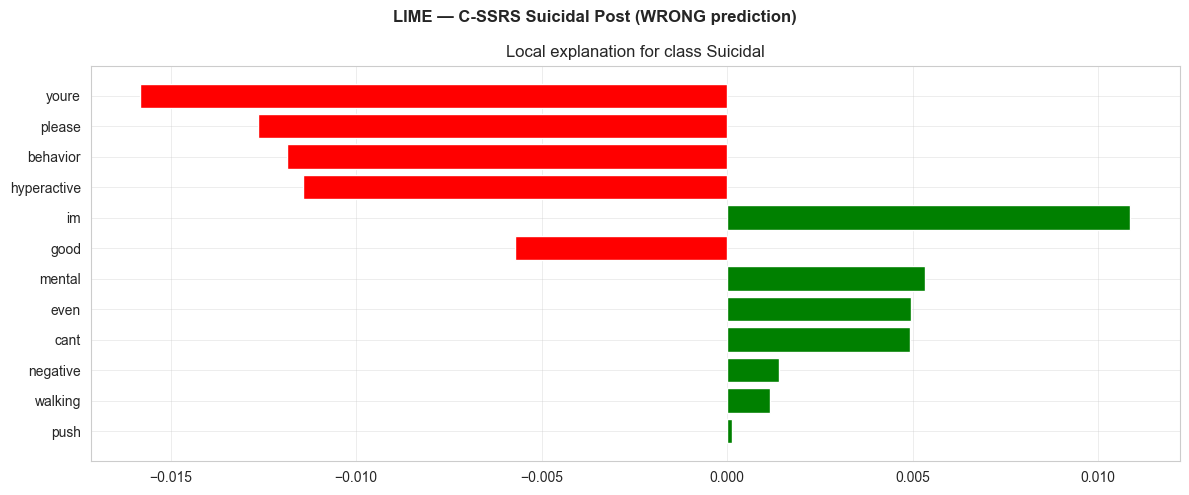

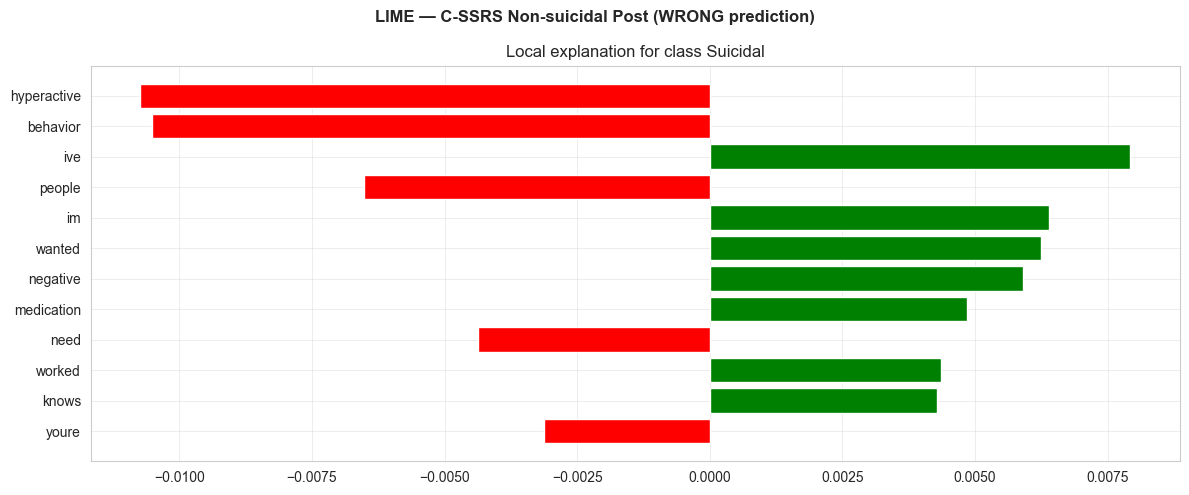

Saved!


In [49]:
fig = exp_cs1.as_pyplot_figure()
fig.suptitle('LIME — C-SSRS Suicidal Post (WRONG prediction)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/lime_cssrs_suicidal.png', dpi=150, bbox_inches='tight')
plt.show()

fig = exp_cs2.as_pyplot_figure()
fig.suptitle('LIME — C-SSRS Non-suicidal Post (WRONG prediction)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/lime_cssrs_non_suicidal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

## LIME Analysis — C-SSRS Dataset

### Key Observation: Both examples were misclassified!

**Suicidal post → predicted Non-suicidal (54% confidence)**  
**Non-suicidal post → predicted Suicidal (51% confidence)**

Both predictions are near 50/50 — the model is essentially guessing.

### Why the model fails on C-SSRS

**1. Words have no clear direction**
- `ive`, `im` push toward Suicidal in both examples
- `behavior`, `hyperactive`, `youre` push toward Non-suicidal in both examples
- The model is using the same weak signals for both classes!

**2. Weights are extremely small**
- Twitter LIME weights: up to ±0.07
- C-SSRS LIME weights: up to ±0.01 (7x smaller!)

This means no single word strongly determines the prediction.
The model has no confident signal to rely on.

**3. The language is clinical and complex**
- C-SSRS posts discuss mental health in nuanced ways
- Words like `depression`, `medication`, `behavior` appear in 
  both suicidal and non-suicidal posts
- TF-IDF cannot distinguish the context in which they are used

### Comparison: Twitter vs C-SSRS LIME

| Property | Twitter | C-SSRS |
|----------|---------|--------|
| Max word weight | ±0.07 | ±0.01 |
| Model confidence | 60–71% | 51–54% |
| Errors | Both correct | Both wrong |
| Key signals | "forever", "sleep", "haha" | No clear signals |

### Conclusion

The LIME analysis on C-SSRS confirms that TF-IDF + Logistic Regression 
has no reliable discriminative signal for this dataset. The model's 
near-random performance (F1 = 0.70) is reflected in the near-zero 
LIME weights and 50/50 confidence scores.

This strongly motivates the use of contextual models (LSTM, BiLSTM, 
GRU, BERT) which can capture long-range dependencies and clinical 
language patterns that TF-IDF fundamentally cannot represent.

In [50]:
# ── Error Analysis ─────────────────────────────────────────────────
# Найдём примеры где модель ошиблась и проанализируем почему

# Get predictions on test set
y_pred_lr = lr_model.predict(X_test)

# Find misclassified examples
errors = pd.DataFrame({
    'text':      X_test.values,
    'true':      y_test.values,
    'predicted': y_pred_lr
})

# Keep only errors
errors = errors[errors['true'] != errors['predicted']].reset_index(drop=True)

# Label names for readability
errors['true_name']      = errors['true'].map({0: 'Non-suicidal', 1: 'Suicidal'})
errors['predicted_name'] = errors['predicted'].map({0: 'Non-suicidal', 1: 'Suicidal'})

print(f'Total errors: {len(errors)}')
print(f'False Positives (said Suicidal, was Non-suicidal): {len(errors[errors["predicted"] == 1])}')
print(f'False Negatives (said Non-suicidal, was Suicidal): {len(errors[errors["predicted"] == 0])}')

Total errors: 42
False Positives (said Suicidal, was Non-suicidal): 33
False Negatives (said Non-suicidal, was Suicidal): 9


Что такое Error Analysis - Это когда ты берёшь примеры где модель ошиблась и пытаешься понять почему. Это один из самых ценных видов анализа в NLP — показывает что модель не умеет делать и что нужно улучшить.

In [51]:
# Look at False Negatives first — most dangerous errors
# Это посты которые РЕАЛЬНО суицидальные, но модель пропустила
fn = errors[errors['predicted'] == 0].reset_index(drop=True)
fp = errors[errors['predicted'] == 1].reset_index(drop=True)

print('=== FALSE NEGATIVES (missed suicidal posts) ===')
print('These are the most dangerous errors!\n')
for i, row in fn.iterrows():
    print(f'[{i+1}] {row["text"]}')
    print()

print('=' * 60)
print('=== FALSE POSITIVES (false alarms) ===')
print('Model said Suicidal but post was Non-suicidal\n')
for i, row in fp.head(10).iterrows():  # show first 10
    print(f'[{i+1}] {row["text"]}')
    print()

=== FALSE NEGATIVES (missed suicidal posts) ===
These are the most dangerous errors!

[1] wife says left updog

[2] think going redecorate living room tired moving stuff around

[3] worst part tire easily love napping fortunately get tired work

[4] asahi giant scared please eat ass spirits

[5] tell psychiatrist suicidal immediately shipped away handcuffed bed always lie

[6] jami probably drunk driver coming onto coming traffic

[7] skill takes time iq center could run bigs floor force teams go small

[8] heart crushed

[9] gene acting bit odd lately told leper wanting jump tree join supe

=== FALSE POSITIVES (false alarms) ===
Model said Suicidal but post was Non-suicidal

[1] want kill

[2] make topic sure get replies soon

[3] im fuckin buy shirt please

[4] whoa want

[5] sure get homework done celebrating poin

[6] bloodstain carpet ready gooo

[7] getting ready class much rather sleep

[8] imagine much howard would want know

[9] get upset worth besides enough people accounts p

## Error Analysis Summary

**Total test samples:** 357  
**Total errors:** 42 (11.8% error rate)  
**False Negatives:** 9 — missed suicidal posts ⚠️  
**False Positives:** 33 — false alarms  

### False Negatives — Why the model missed suicidal posts

- **Short posts after preprocessing** lose critical context — some posts became only 3-4 words
- **Indirect/euphemistic language** is not captured — "tired of moving stuff around" may mask suicidal intent
- **Fear of consequences** posts use unusual vocabulary — *"tell psychiatrist suicidal immediately shipped away handcuffed"* — the model had not seen this pattern

### False Positives — Why the model raised false alarms

- Words like **"tired", "sleep", "want", "kill"** appear in everyday non-suicidal contexts
- The model cannot distinguish *"tired of work"* from *"tired of living"*
- Ambiguous short posts like *"want kill"* or *"tired everything"* are misclassified without full sentence context

### Key Insight

> TF-IDF treats each word independently and cannot capture **context**. The same words mean completely different things in different situations. This is the fundamental limitation that motivates the use of LSTM, BiLSTM, GRU, and BERT in subsequent experiments.